In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from imblearn.over_sampling import SMOTE
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score
from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_val_score
from imblearn.over_sampling import SMOTE

import re
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dropout, Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import SpatialDropout1D, Activation

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving financial sentiment analysis.csv to financial sentiment analysis (1).csv


In [ ]:
df = pd.read_csv('financial sentiment analysis.csv')

In [ ]:
df.head()

,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [ ]:
#missing values
df.isnull().sum()

,0
Sentence,0
Sentiment,0


In [ ]:
df.duplicated().sum()

np.int64(6)

In [ ]:
#remove the duplicates
df=df.drop_duplicates()

<ipython-input-10-067a388398a8>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Sentiment",data=df,palette="Set2")


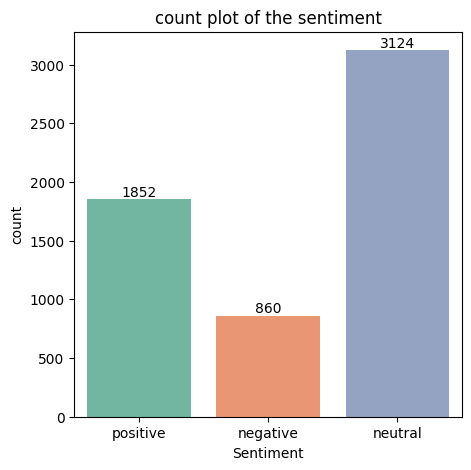

In [ ]:
#count plot for sentiment column

plt.figure(figsize=(5,5))
sns.countplot(x="Sentiment",data=df,palette="Set2")
plt.title("count plot of the sentiment")

# Adding data labels on top of the bars
for bar in plt.gca().patches:
    height = bar.get_height()
    x = bar.get_x() + bar.get_width() / 2
    plt.text(x, height, str(int(height)), ha='center', va='bottom')

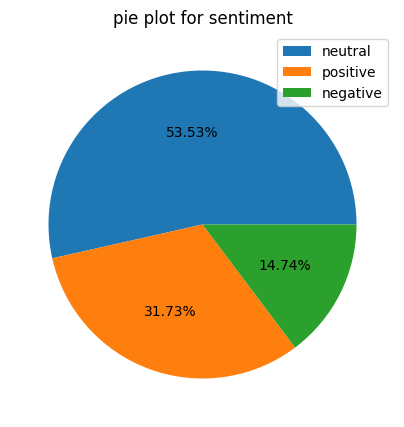

In [ ]:
#pie plot for sentiment column

labels=["neutral","positive","negative"]
plt.figure(figsize=(5,5))
plt.pie(x=df["Sentiment"].value_counts(),autopct="%0.2f%%")
plt.title("pie plot for sentiment")
plt.legend(labels)

In [ ]:
#applying label encoding to sentiment column

le=LabelEncoder()
df["Sentiment"]=le.fit_transform(df["Sentiment"])

df["Sentiment"].unique()

array([2, 0, 1])

In [ ]:
#cleaning

stop=set(stopwords.words("english"))
lemmatizer=WordNetLemmatizer()


def clean_text(text):
    text = re.sub(r"won\'t", "will not", text)
    text = re.sub(r"can\'t", "can not", text)
    text = re.sub(r"n\'t", " not", text)
    text = re.sub(r"\'re", " are", text)
    text = re.sub(r"\'s", " is", text)
    text = re.sub(r"\'d", " would",text)
    text = re.sub(r"\'ll", " will", text)
    text = re.sub(r"\'t", " not", text)
    text = re.sub(r"\'ve", " have", text)
    text = re.sub(r"\'m", " am", text)
    text = re.sub('[^a-zA-Z]',' ',text)
    text = re.sub(r"[^\w\s]"," ",text.lower())
    text = re.sub(r"\s+"," ",text)
    tokens=word_tokenize(text)
    output=[lemmatizer.lemmatize(words) for words in tokens if words.isalpha() and words not in stop]
    return " ".join(output)


In [ ]:

df["clean text"]=df["Sentence"].apply(clean_text)

In [ ]:
#Creating the Bag of Words model (BoW)
#countvectorizer

vectorizer=CountVectorizer()
x=vectorizer.fit_transform(df["clean text"])
y=df["Sentiment"]

In [ ]:
#balnce the sentiment column

smote=SMOTE()

x,y=smote.fit_resample(x,y)

print(y.value_counts())

Sentiment
2    3124
0    3124
1    3124
Name: count, dtype: int64


In [ ]:
#train_test split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
models={"LogisticRegression":LogisticRegression(),
        "Naive Bayes":MultinomialNB(),
        "SVC":SVC(),
        "KNN":KNeighborsClassifier(),
        "xgboost":XGBClassifier()}


for name, model in models.items():
    if name=="Naive Bayes":
        model.fit(x_train.toarray(),y_train)
        y_pred_train=model.predict(x_train.toarray())
        y_pred=model.predict(x_test.toarray())

    else:
        model.fit(x_train,y_train)
        y_pred_train=model.predict(x_train)
        y_pred=model.predict(x_test)

    print(f"{name}")
    print("train accuracy: ",accuracy_score(y_train,y_pred_train))
    print("test accuracy: ",accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print("*"*50)

LogisticRegression
train accuracy:  0.8486061091103108
test accuracy:  0.6725333333333333
              precision    recall  f1-score   support

           0       0.60      0.82      0.69       623
           1       0.75      0.65      0.69       642
           2       0.72      0.55      0.62       610

    accuracy                           0.67      1875
   macro avg       0.69      0.67      0.67      1875
weighted avg       0.69      0.67      0.67      1875

[[511  71  41]
 [136 417  89]
 [206  71 333]]
**************************************************
Naive Bayes
train accuracy:  0.720688275310124
test accuracy:  0.6256
              precision    recall  f1-score   support

           0       0.57      0.51      0.54       623
           1       0.74      0.74      0.74       642
           2       0.56      0.63      0.59       610

    accuracy                           0.63      1875
   macro avg       0.62      0.62      0.62      1875
weighted avg       0.63      0.63   

In [ ]:
#TF_IDF vectorizer

tfvectorizer=TfidfVectorizer()
x=tfvectorizer.fit_transform(df["clean text"])
y=df["Sentiment"]

In [ ]:
#balnce the sentiment column

smote=SMOTE()

x,y=smote.fit_resample(x,y)

print(y.value_counts())

Sentiment
2    3124
0    3124
1    3124
Name: count, dtype: int64


In [ ]:
for name, model in models.items():
    if name=="Naive Bayes":
        model.fit(x_train.toarray(),y_train)
        y_pred_train=model.predict(x_train.toarray())
        y_pred=model.predict(x_test.toarray())

    else:
        model.fit(x_train,y_train)
        y_pred_train=model.predict(x_train)
        y_pred=model.predict(x_test)

    print(f"{name}")
    print("train accuracy: ",accuracy_score(y_train,y_pred_train))
    print("test accuracy: ",accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print("*"*50)

LogisticRegression
train accuracy:  0.8486061091103108
test accuracy:  0.6725333333333333
              precision    recall  f1-score   support

           0       0.60      0.82      0.69       623
           1       0.75      0.65      0.69       642
           2       0.72      0.55      0.62       610

    accuracy                           0.67      1875
   macro avg       0.69      0.67      0.67      1875
weighted avg       0.69      0.67      0.67      1875

[[511  71  41]
 [136 417  89]
 [206  71 333]]
**************************************************
Naive Bayes
train accuracy:  0.720688275310124
test accuracy:  0.6256
              precision    recall  f1-score   support

           0       0.57      0.51      0.54       623
           1       0.74      0.74      0.74       642
           2       0.56      0.63      0.59       610

    accuracy                           0.63      1875
   macro avg       0.62      0.62      0.62      1875
weighted avg       0.63      0.63   

# ***cross validation ***


----- Model: LogisticRegression -----
Fold 0 - Precision: 0.6866, Recall: 0.6866
Fold 1 - Precision: 0.6650, Recall: 0.6650
Fold 2 - Precision: 0.6675, Recall: 0.6675
Fold 3 - Precision: 0.6632, Recall: 0.6632
Fold 4 - Precision: 0.6504, Recall: 0.6504

Average Precision for LogisticRegression: 0.6665
Average Recall for LogisticRegression: 0.6665

Classification Report (last fold):
              precision    recall  f1-score   support

           2       0.71      0.65      0.68       371
           0       0.30      0.24      0.27       172
           1       0.69      0.76      0.73       624

    accuracy                           0.65      1167
   macro avg       0.57      0.55      0.56      1167
weighted avg       0.64      0.65      0.64      1167

************************************************************

----- Model: Naive Bayes -----
Fold 0 - Precision: 0.6849, Recall: 0.6849
Fold 1 - Precision: 0.6667, Recall: 0.6667
Fold 2 - Precision: 0.6975, Recall: 0.6975
Fold 3 - Pr

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:55:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 0 - Precision: 0.6841, Recall: 0.6841


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:55:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 1 - Precision: 0.6632, Recall: 0.6632


...

Fold 2 - Precision: 0.6769, Recall: 0.6769


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:55:20] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 3 - Precision: 0.6727, Recall: 0.6727


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:55:23] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 4 - Precision: 0.6812, Recall: 0.6812

Average Precision for XGBoost: 0.6756
Average Recall for XGBoost: 0.6756

Classification Report (last fold):
              precision    recall  f1-score   support

           2       0.78      0.59      0.67       371
           0       0.39      0.22      0.28       172
           1       0.68      0.86      0.76       624

    accuracy                           0.68      1167
   macro avg       0.62      0.56      0.57      1167
weighted avg       0.67      0.68      0.66      1167

************************************************************


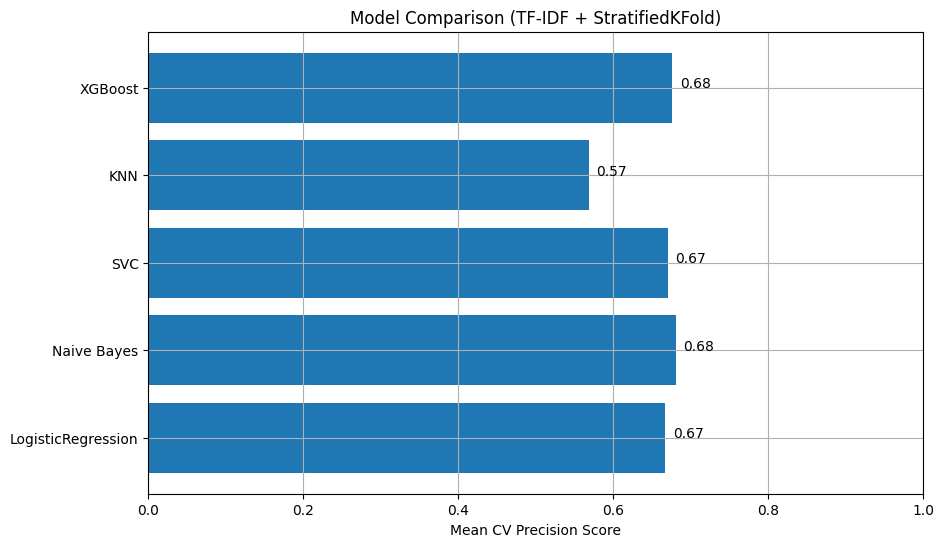

In [ ]:
# cross validation and Count vectorizer

# Shuffle and prepare data
df = df.sample(frac=1).reset_index(drop=True)
df['fold'] = -1

# Set input (text) and target (label)
x = df["clean text"]
y = df['Sentiment']

# 5-Fold setup
n = 5
kf = StratifiedKFold(n_splits=n)

# Assign fold numbers
for k, (train_idx, test_idx) in enumerate(kf.split(x, y)):
    df.loc[test_idx, 'fold'] = k

# Define models
models = {
    "LogisticRegression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Create dictionary to save results
results = {}

# Try each model
for model_name, model_instance in models.items():
    print(f"\n----- Model: {model_name} -----")

    precision_scores = []
    recall_scores = []

    for k in range(n):
        train = df[df.fold != k].reset_index(drop=True)
        test = df[df.fold == k].reset_index(drop=True)

        # Create a fresh TF-IDF vectorizer for every fold
        vectorizer = CountVectorizer()

        # Fit vectorizer only on training text
        vectorizer.fit(train["clean text"])

        # Transform texts into vectors
        x_train = vectorizer.transform(train["clean text"])
        y_train = train["Sentiment"]

        x_test = vectorizer.transform(test["clean text"])
        y_test = test["Sentiment"]

        # Create a new model instance for each fold
        model = model_instance.__class__(**model_instance.get_params())
        model.fit(x_train, y_train)

        # Predict
        preds = model.predict(x_test)

        # Metrics
        precision = precision_score(y_test, preds, average='micro')
        recall = recall_score(y_test, preds, average='micro')

        precision_scores.append(precision)
        recall_scores.append(recall)

        print(f"Fold {k} - Precision: {precision:.4f}, Recall: {recall:.4f}")

    # After all folds, show average scores
    avg_precision = sum(precision_scores) / n
    avg_recall = sum(recall_scores) / n

    print(f"\nAverage Precision for {model_name}: {avg_precision:.4f}")
    print(f"Average Recall for {model_name}: {avg_recall:.4f}")

    # Save average precision for plotting
    results[model_name] = avg_precision

    # Show final classification report (for last fold)
    print("\nClassification Report (last fold):")
    print(classification_report(y_test, preds, labels=[2, 0, 1]))
    print("*" * 60)

# =====================
# Now Plotting Results
# =====================

model_names = list(results.keys())
average_precisions = list(results.values())

plt.figure(figsize=(10,6))
plt.barh(model_names, average_precisions)
plt.xlabel("Mean CV Precision Score")
plt.title("Model Comparison (TF-IDF + StratifiedKFold)")
for index, value in enumerate(average_precisions):
    plt.text(value + 0.01, index, f"{value:.2f}")
plt.xlim(0, 1)
plt.grid(True)
plt.show()


----- Model: LogisticRegression -----
Fold 0 - Precision: 0.6961, Recall: 0.6961
Fold 1 - Precision: 0.6898, Recall: 0.6898
Fold 2 - Precision: 0.6907, Recall: 0.6907
Fold 3 - Precision: 0.6992, Recall: 0.6992
Fold 4 - Precision: 0.6984, Recall: 0.6984

Average Precision for LogisticRegression: 0.6948
Average Recall for LogisticRegression: 0.6948

Classification Report (last fold):
              precision    recall  f1-score   support

           2       0.76      0.61      0.68       370
           0       0.47      0.16      0.24       172
           1       0.69      0.90      0.78       625

    accuracy                           0.70      1167
   macro avg       0.64      0.56      0.57      1167
weighted avg       0.68      0.70      0.67      1167

************************************************************

----- Model: Naive Bayes -----
Fold 0 - Precision: 0.6592, Recall: 0.6592
Fold 1 - Precision: 0.6684, Recall: 0.6684
Fold 2 - Precision: 0.6632, Recall: 0.6632
Fold 3 - Pr

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:56:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 0 - Precision: 0.6558, Recall: 0.6558


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:56:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 1 - Precision: 0.6641, Recall: 0.6641


...

Fold 2 - Precision: 0.6624, Recall: 0.6624


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:56:35] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 3 - Precision: 0.6701, Recall: 0.6701


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [19:56:43] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Fold 4 - Precision: 0.6692, Recall: 0.6692

Average Precision for XGBoost: 0.6643
Average Recall for XGBoost: 0.6643

Classification Report (last fold):
              precision    recall  f1-score   support

           2       0.83      0.57      0.68       370
           0       0.33      0.22      0.26       172
           1       0.67      0.85      0.75       625

    accuracy                           0.67      1167
   macro avg       0.61      0.55      0.56      1167
weighted avg       0.67      0.67      0.65      1167

************************************************************


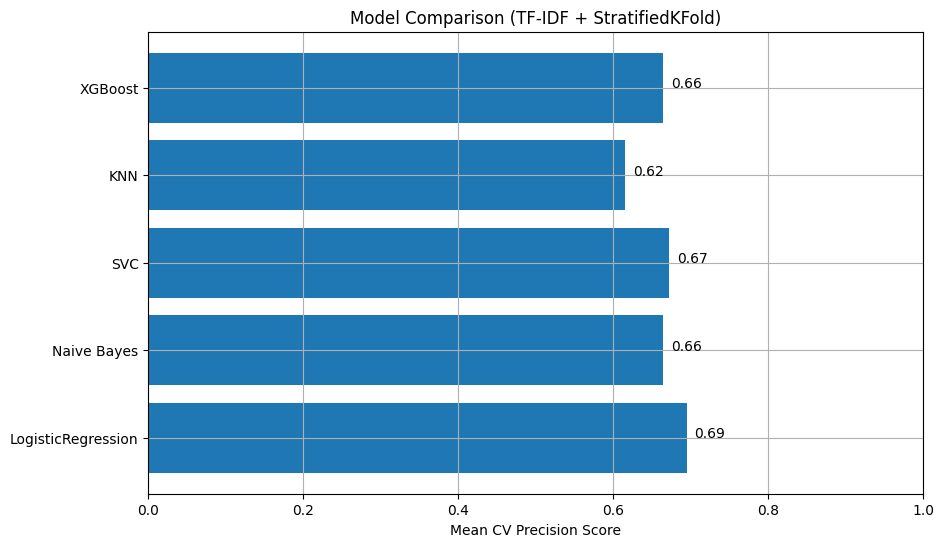

In [ ]:
#cross validation for selected models in TF_IDF vectorizer

# Shuffle and prepare data
df = df.sample(frac=1).reset_index(drop=True)
df['fold'] = -1

# Set input (text) and target (label)
x = df["clean text"]
y = df['Sentiment']

# 5-Fold setup
n = 5
kf = StratifiedKFold(n_splits=n)

# Assign fold numbers
for k, (train_idx, test_idx) in enumerate(kf.split(x, y)):
    df.loc[test_idx, 'fold'] = k

# Define models
models = {
    "LogisticRegression": LogisticRegression(),
    "Naive Bayes": MultinomialNB(),
    "SVC": SVC(),
    "KNN": KNeighborsClassifier(),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='mlogloss')
}

# Create dictionary to save results
results = {}

# Try each model
for model_name, model_instance in models.items():
    print(f"\n----- Model: {model_name} -----")

    precision_scores = []
    recall_scores = []

    for k in range(n):
        train = df[df.fold != k].reset_index(drop=True)
        test = df[df.fold == k].reset_index(drop=True)

        # Create a fresh TF-IDF vectorizer for every fold
        vectorizer = TfidfVectorizer()

        # Fit vectorizer only on training text
        vectorizer.fit(train["clean text"])

        # Transform texts into vectors
        x_train = vectorizer.transform(train["clean text"])
        y_train = train["Sentiment"]

        x_test = vectorizer.transform(test["clean text"])
        y_test = test["Sentiment"]

        # Create a new model instance for each fold
        model = model_instance.__class__(**model_instance.get_params())
        model.fit(x_train, y_train)

        # Predict
        preds = model.predict(x_test)

        # Metrics
        precision = precision_score(y_test, preds, average='micro')
        recall = recall_score(y_test, preds, average='micro')

        precision_scores.append(precision)
        recall_scores.append(recall)

        print(f"Fold {k} - Precision: {precision:.4f}, Recall: {recall:.4f}")

    # After all folds, show average scores
    avg_precision = sum(precision_scores) / n
    avg_recall = sum(recall_scores) / n

    print(f"\nAverage Precision for {model_name}: {avg_precision:.4f}")
    print(f"Average Recall for {model_name}: {avg_recall:.4f}")

    # Save average precision for plotting
    results[model_name] = avg_precision

    # Show final classification report (for last fold)
    print("\nClassification Report (last fold):")
    print(classification_report(y_test, preds, labels=[2, 0, 1]))
    print("*" * 60)

# =====================
# Now Plotting Results
# =====================

model_names = list(results.keys())
average_precisions = list(results.values())

plt.figure(figsize=(10,6))
plt.barh(model_names, average_precisions)
plt.xlabel("Mean CV Precision Score")
plt.title("Model Comparison (TF-IDF + StratifiedKFold)")
for index, value in enumerate(average_precisions):
    plt.text(value + 0.01, index, f"{value:.2f}")
plt.xlim(0, 1)
plt.grid(True)
plt.show()

# **Lexicon-Based (VADER, TextBlob)**

In [ ]:
!pip install vaderSentiment

In [ ]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from textblob import TextBlob

analyser=SentimentIntensityAnalyzer()

def get_sentiment(text):
    return analyser.polarity_scores(str(text))

df["clean text"].apply(get_sentiment)[1]

{'neg': 0.0, 'neu': 0.647, 'pos': 0.353, 'compound': 0.5994}

In [ ]:
#subjectivity and polarity from textblob

def get_subjectivity(text):
    return TextBlob(text).sentiment.subjectivity

def get_polarity(text):
    return TextBlob(text).sentiment.polarity

In [ ]:
#creating compound,neg, pos and neu
compound=[]
neg=[]
pos=[]
neu=[]

for i in range(0, len(df["clean text"])):
    SIA=get_sentiment(df["clean text"].iloc[i])
    compound.append(SIA["compound"])
    neg.append(SIA["neg"])
    pos.append(SIA["pos"])
    neu.append(SIA["neu"])

df["compound"]=compound
df["neg"]=neg
df["pos"]=pos
df["neu"]=neu

In [ ]:
df["subjectivity"]=df["clean text"].apply(get_subjectivity)
df["polarity"]=df["clean text"].apply(get_polarity)

In [ ]:
#linear Discrminant analysis

x=df[["compound","neg","pos","neu","subjectivity","polarity"]]
y=df["Sentiment"]

smote=SMOTE()
x,y=smote.fit_resample(x,y)

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

lda=LinearDiscriminantAnalysis()
model=lda.fit(x_train,y_train)
y_pred=model.predict(x_test)
y_pred_train=model.predict(x_train)
print("train accuracy: ",accuracy_score(y_train,y_pred_train))
print("test_accuracy: ",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

train accuracy:  0.5064692543684141
test_accuracy:  0.5136
              precision    recall  f1-score   support

           0       0.64      0.44      0.52       619
           1       0.45      0.55      0.49       608
           2       0.50      0.55      0.53       648

    accuracy                           0.51      1875
   macro avg       0.53      0.51      0.51      1875
weighted avg       0.53      0.51      0.51      1875



In [ ]:
models={"LogisticRegression":LogisticRegression(),
        "LDA":LinearDiscriminantAnalysis(),
        "SVC":SVC(),
        "KNN":KNeighborsClassifier(),
        "xgboost":XGBClassifier()}


for name, model in models.items():
    if name=="LDA":
        model.fit(x_train,y_train)
        y_pred_train=model.predict(x_train)
        y_pred=model.predict(x_test)

    else:
        model.fit(x_train,y_train)
        y_pred_train=model.predict(x_train)
        y_pred=model.predict(x_test)

    print(f"{name}")
    print("train accuracy: ",accuracy_score(y_train,y_pred_train))
    print("test accuracy: ",accuracy_score(y_test,y_pred))
    print(classification_report(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print("*"*50)

LogisticRegression
train accuracy:  0.5056689342403629
test accuracy:  0.5136
              precision    recall  f1-score   support

           0       0.63      0.44      0.52       619
           1       0.45      0.53      0.48       608
           2       0.51      0.57      0.54       648

    accuracy                           0.51      1875
   macro avg       0.53      0.51      0.51      1875
weighted avg       0.53      0.51      0.51      1875

[[273 193 153]
 [ 82 320 206]
 [ 76 202 370]]
**************************************************
LDA
train accuracy:  0.5064692543684141
test accuracy:  0.5136
              precision    recall  f1-score   support

           0       0.64      0.44      0.52       619
           1       0.45      0.55      0.49       608
           2       0.50      0.55      0.53       648

    accuracy                           0.51      1875
   macro avg       0.53      0.51      0.51      1875
weighted avg       0.53      0.51      0.51      1875



"We took numbers from VADER and TextBlob that describe the feeling of each text (like how positive or negative it is). Then, we used these numbers to train different machine learning models to predict the sentiment.

The models were about 50–60% correct, which means these simple sentiment scores give some useful information, but not enough to make very strong predictions.

To do better in the future, we would need more powerful tools that understand financial language better, like a model called FinBERT, or use deeper machine learning methods that learn from full sentences."

In this project, I performed sentiment classification on financial news headlines using a complete machine learning pipeline. I applied text preprocessing, feature engineering (TF-IDF, CountVectorizer, VADER, TextBlob), handled class imbalance with SMOTE, and trained multiple models including Logistic Regression, Naive Bayes, SVM, KNN, XGBoost, and LDA. I compared the performance of different vectorization techniques and sentiment-based features through cross-validation and visualization.



# **GloVe**

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving glove.6B.100d.txt to glove.6B.100d.txt


In [ ]:
def load_glove_vectors(filepath):
    embeddings = {}
    with open(filepath, 'r', encoding="utf8") as f:
        for line in f:
            values = line.split()
            word = values[0]
            vector = np.array(values[1:], dtype='float32')
            embeddings[word] = vector
    return embeddings

# ✅ Use correct path for Colab (not your computer!)
glove_path = 'glove.6B.100d.txt'  # this exists in Colab now
glove_embeddings = load_glove_vectors(glove_path)

In [ ]:
# Convert sentence to vector
def sentence_to_glove_vec(sentence, embeddings, dim=100):
    words = word_tokenize(sentence.lower())
    word_vectors = []
    for word in words:
        if word in embeddings:
            word_vectors.append(embeddings[word])
    if len(word_vectors) == 0:
        return np.zeros(dim)
    word_vectors = np.array(word_vectors)
    return word_vectors.mean(axis=0)

# Build all sentence vectors
sentence_vectors = []
for text in df["clean text"]:
    vec = sentence_to_glove_vec(text, glove_embeddings, dim=100)
    sentence_vectors.append(vec)

sentence_vectors = np.array(sentence_vectors)


In [ ]:
#train test split
x = np.array([sentence_to_glove_vec(text, glove_embeddings) for text in df["clean text"]])
y = df["Sentiment"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [ ]:
# Train a Machine Learning model Logistic Regression


model = LogisticRegression()
model.fit(x_train, y_train)

y_pred_train=model.predict(x_train)
y_pred = model.predict(x_test)


print("train_accuracy: ",accuracy_score(y_train,y_pred_train))
print("test accuracy: ",accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

train_accuracy:  0.6838046272493573
test accuracy:  0.6506849315068494
              precision    recall  f1-score   support

           0       0.47      0.26      0.34       185
           1       0.70      0.83      0.76       613
           2       0.61      0.55      0.58       370

    accuracy                           0.65      1168
   macro avg       0.59      0.55      0.56      1168
weighted avg       0.63      0.65      0.63      1168



In [ ]:
# Train a Machine Learning model SVM

model = SVC()
model.fit(x_train, y_train)

y_pred_train=model.predict(x_train)
y_pred = model.predict(x_test)


print("train_accuracy: ",accuracy_score(y_train,y_pred_train))
print("test accuracy: ",accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))

train_accuracy:  0.7234361610968295
test accuracy:  0.666095890410959
              precision    recall  f1-score   support

           0       0.56      0.10      0.17       185
           1       0.68      0.89      0.77       613
           2       0.64      0.58      0.61       370

    accuracy                           0.67      1168
   macro avg       0.63      0.52      0.52      1168
weighted avg       0.65      0.67      0.62      1168



In [ ]:
# Train a Machine Learning model KNN

model = KNeighborsClassifier()
model.fit(x_train, y_train)

y_pred_train=model.predict(x_train)
y_pred = model.predict(x_test)


print("train_accuracy: ",accuracy_score(y_train,y_pred_train))
print("test accuracy: ",accuracy_score(y_test,y_pred))
print(classification_report(y_test, y_pred))


train_accuracy:  0.7345758354755784
test accuracy:  0.5727739726027398
              precision    recall  f1-score   support

           0       0.19      0.15      0.17       185
           1       0.67      0.73      0.70       613
           2       0.54      0.52      0.53       370

    accuracy                           0.57      1168
   macro avg       0.47      0.47      0.47      1168
weighted avg       0.55      0.57      0.56      1168



# **LSTM**

In [ ]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(df["clean text"])
sequences=tokenizer.texts_to_sequences(df["clean text"])

In [ ]:
max_len=max(len(x) for x in sequences)
print(max_len)

41


In [ ]:
x=pad_sequences(sequences,maxlen=max_len)
y=np.array(df["Sentiment"])

print(x.shape)
print(y.shape)

(5836, 41)
(5836,)


In [ ]:
#LSTM
model=Sequential()
model.add(Embedding(input_dim=len(tokenizer.word_index)+1, output_dim=100, input_length=max_len))
model.add(LSTM(128,return_sequences=True))
model.add(Dropout(0.6))
model.add(LSTM(64))
model.add(Dropout(0.6))
model.add(Dense(3,activation="softmax"))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
print(x_train.shape)
print(x_test.shape)

(4668, 41)
(1168, 41)


In [ ]:
model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [ ]:
early_stop=EarlyStopping(monitor="val_loss",patience=3, restore_best_weights=True)

model.fit(x_train,y_train, epochs=20, batch_size=64 ,validation_data=(x_test,y_test), callbacks=[early_stop])

Epoch 1/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 22s 216ms/step - accuracy: 0.4969 - loss: 1.0116 - val_accuracy: 0.5616 - val_loss: 0.9186
Epoch 2/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 21s 222ms/step - accuracy: 0.6529 - loss: 0.8036 - val_accuracy: 0.6652 - val_loss: 0.7982
Epoch 3/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 225ms/step - accuracy: 0.7981 - loss: 0.5074 - val_accuracy: 0.6567 - val_loss: 0.8423
Epoch 4/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 168ms/step - accuracy: 0.8631 - loss: 0.3263 - val_accuracy: 0.6498 - val_loss: 1.0199
Epoch 5/20
73/73 ━━━━━━━━━━━━━━━━━━━━ 21s 170ms/step - accuracy: 0.8806 - loss: 0.2531 - val_accuracy: 0.6490 - val_loss: 1.1475


In [ ]:
model.evaluate(x_test,y_test)

37/37 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.6885 - loss: 0.7717


[0.7981588840484619, 0.6652397513389587]

as we see there is ovrfitting in LSTM method and also the val_loss has increased after the second epoch which means after epoch 2 we have overfitting, the val_accuracy in the epoch 5 is better than the others but its val_loss is high, so it is better to use other method


# **LSTM with GloVe**

In [ ]:
embedding_dim=100

#load GloVe embeddings
glove_dict={}

with open("glove.6B.100d.txt",encoding="utf8") as f:
  for line in f:
    values=line.split()
    word=values[0]
    vector=np.asarray(values[1:],dtype="float32")
    glove_dict[word]=vector


In [ ]:
tokenizer=Tokenizer()
tokenizer.fit_on_texts(df["clean text"])
sequences=tokenizer.texts_to_sequences(df["clean text"])

In [ ]:
max_len=max(len(x) for x in sequences)
vocab_size=len(tokenizer.word_index)+1

In [ ]:
embedding_matrix=np.zeros((vocab_size,embedding_dim))

for word, i in tokenizer.word_index.items():
  embedding_vector=glove_dict.get(word)
  if embedding_vector is not None:
    embedding_matrix[i]=embedding_vector

In [ ]:
x=pad_sequences(sequences,maxlen=max_len)
y=df["Sentiment"]

In [ ]:
#one-hot encoding
from tensorflow.keras.utils import to_categorical

num_class=len(np.unique(y))

y=to_categorical(y,num_classes=num_class)

print(y.shape)

(5836, 3)


In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(4668, 41)
(1168, 41)
(4668, 3)
(1168, 3)


In [ ]:
model = Sequential()

# Embedding layer using GloVe
model.add(Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix],input_length=max_len,trainable=False))

model.add(SpatialDropout1D(0.3))
model.add(LSTM(100, dropout=0.3, recurrent_dropout=0.3))

model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.8))

model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.8))

model.add(Dense(3))
model.add(Activation('softmax'))

model.compile(loss='categorical_crossentropy',optimizer='adam', metrics=[tf.keras.metrics.Precision()])

In [ ]:
model.fit(x_train, y_train, epochs=25, batch_size=64, validation_data=(x_test, y_test))

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 145ms/step - loss: 1.0109 - precision_3: 0.5505 - val_loss: 0.9238 - val_precision_3: 0.7297
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 19s 123ms/step - loss: 0.9496 - precision_3: 0.6402 - val_loss: 0.8855 - val_precision_3: 0.7366
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 114ms/step - loss: 0.9020 - precision_3: 0.6666 - val_loss: 0.8753 - val_precision_3: 0.7534
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 122ms/step - loss: 0.9009 - precision_3: 0.6628 - val_loss: 0.8649 - val_precision_3: 0.7758
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 11s 131ms/step - loss: 0.8862 - precision_3: 0.6709 - val_loss: 0.8290 - val_precision_3: 0.7395
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 13s 172ms/step - loss: 0.8686 - precision_3: 0.6657 - val_loss: 0.8320 - val_precision_3: 0.7285
Epoch 7/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 18s 133ms/step - loss: 0.8567 - precision_3: 0.6740 - val_loss: 0.8374 - val_precision_3: 0.7612
Epoch 8/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 17s 220ms/step - 

Precision (training and validation) is consistently good — training precision reaches ~0.84, and validation precision stays around ~0.77–0.78.

The model isn't overfitting severely — precision doesn't collapse, and the validation scores are stable.

Validation loss is not consistently decreasing — it bounces around 0.63 to 0.69, suggesting the model is not learning much new after ~epoch 9.

After epoch 9, validation precision stops improving, which is a sign of early convergence (the model is done learning).

Training continues unnecessarily after epoch 10–15, which wastes time and might risk overfitting. so we Use EarlyStopping

# **LSTM Glov and early stopping**

In [ ]:
model = Sequential()
model.add(Embedding(len(tokenizer.word_index) + 1,100,weights=[embedding_matrix],trainable=False))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(100, dropout=0.3, recurrent_dropout=0.3))

model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.8))

model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.8))

model.add(Dense(3))
model.add(Activation('softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics = [tf.keras.metrics.Precision()])


In [ ]:

# Fit the model with early stopping callback
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, verbose=0, mode='auto')

model.fit(x_train, y=y_train, batch_size=64, epochs=25,
          verbose=1, validation_data = (x_test,y_test), callbacks=[earlystop])

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 30s 240ms/step - loss: 1.0160 - precision_5: 0.5592 - val_loss: 0.9339 - val_precision_5: 0.7441
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 142ms/step - loss: 0.9281 - precision_5: 0.6546 - val_loss: 0.9108 - val_precision_5: 0.7895
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 12s 166ms/step - loss: 0.9113 - precision_5: 0.6594 - val_loss: 0.8669 - val_precision_5: 0.7617
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 23s 206ms/step - loss: 0.8781 - precision_5: 0.6676 - val_loss: 0.8617 - val_precision_5: 0.7784
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 14s 114ms/step - loss: 0.8734 - precision_5: 0.6859 - val_loss: 0.8328 - val_precision_5: 0.7567
Epoch 6/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 110ms/step - loss: 0.8527 - precision_5: 0.6723 - val_loss: 0.8394 - val_precision_5: 0.7852
Epoch 7/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 10s 139ms/step - loss: 0.8574 - precision_5: 0.6801 - val_loss: 0.8177 - val_precision_5: 0.7586
Epoch 8/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 127ms/step - 

training precision improved from 0.54 to 0.78. Validation precision remained consistently high (0.76–0.80), this shows stable generalization. Validation loss gradually dropped from 0.89 → 0.65, meaning your model became more confident in its predictions on unseen data. model learned steadily without overfitting The EarlyStopping helped prevent wasting time after model performance plateaued. The final precision of 0.7881 on validation is strong LSTM model with GloVe embeddings, trained with EarlyStopping, achieved stable and strong validation precision (~0.79) with decreasing loss, showing that it learned the task well and generalized safely. EarlyStopping ensured that you didn’t train unnecessarily long after reaching peak performance.

# **bidirectional LSTM**

In [ ]:
from tensorflow.keras.layers import Bidirectional

model_bi = Sequential()
model_bi.add(Embedding(len(tokenizer.word_index)+1, 100, weights=[embedding_matrix], trainable = False))

model_bi.add(SpatialDropout1D(0.3))
model_bi.add(Bidirectional(LSTM(300, dropout = 0.3, recurrent_dropout = 0.3)))

model_bi.add(Dense(1024, activation = 'relu'))
model_bi.add(Dropout(0.8))

model_bi.add(Dense(1024, activation = 'relu'))
model_bi.add(Dropout(0.8))

model_bi.add(Dense(3))
model_bi.add(Activation('softmax'))

In [ ]:
model_bi.compile(loss='categorical_crossentropy',optimizer='adam',
                 metrics=['accuracy',tf.keras.metrics.Precision(),tf.keras.metrics.Recall()])

In [ ]:
earlystop = EarlyStopping(monitor = 'val_loss', min_delta = 0, patience = 3, verbose = 0, mode = 'auto')

model_bi.fit(x_train, y=y_train, batch_size=64, epochs=25, verbose=1,validation_data=(x_test, y_test), callbacks=[earlystop])

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.5015 - loss: 1.0195 - precision_8: 0.5114 - recall_2: 0.3022 - val_accuracy: 0.5882 - val_loss: 0.9282 - val_precision_8: 0.7676 - val_recall_2: 0.2517
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 87s 1s/step - accuracy: 0.5644 - loss: 0.9377 - precision_8: 0.6402 - recall_2: 0.3801 - val_accuracy: 0.6104 - val_loss: 0.8708 - val_precision_8: 0.7614 - val_recall_2: 0.3279
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.5767 - loss: 0.9041 - precision_8: 0.6640 - recall_2: 0.4239 - val_accuracy: 0.6104 - val_loss: 0.8657 - val_precision_8: 0.7709 - val_recall_2: 0.3313
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 82s 1s/step - accuracy: 0.5909 - loss: 0.8875 - precision_8: 0.6629 - recall_2: 0.4367 - val_accuracy: 0.6276 - val_loss: 0.8473 - val_precision_8: 0.7528 - val_recall_2: 0.3493
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 84s 1s/step - accuracy: 0.5739 - loss: 0.8764 - precision_8: 0.6657 - recall_2: 0.4294 - val_accur

# **GRU model**

In [ ]:
from tensorflow.keras.layers import GRU

model_gru = Sequential()
model_gru.add(Embedding(len(tokenizer.word_index)+1, 100, weights = [embedding_matrix], trainable=False))

model_gru.add(SpatialDropout1D(0.3))
model_gru.add(GRU(100, dropout=0.3, recurrent_dropout=0.3, return_sequences = True))
model_gru.add(GRU(100, dropout = 0.3, recurrent_dropout = 0.3))

model_gru.add(Dense(1024, activation = 'relu'))
model_gru.add(Dropout(0.8))

model_gru.add(Dense(1024, activation = 'relu'))
model_gru.add(Dropout(0.8))

model_gru.add(Dense(3, activation = 'softmax'))


In [ ]:
model_gru.compile(loss='categorical_crossentropy',
                 optimizer='adam',metrics=[
    'accuracy',
    tf.keras.metrics.Precision(),
    tf.keras.metrics.Recall()
])

In [ ]:
earlystop = EarlyStopping(monitor = 'val_loss', min_delta = 0, patience = 3, verbose = 0, mode= 'auto')

model_gru.fit(x_train, y=y_train, batch_size=64, epochs=25, verbose=1, validation_data = (x_test, y_test),callbacks = [earlystop])

y_pred = model_gru.predict(x_test)

print(classification_report(np.argmax(y_test, axis=1), np.argmax(y_pred , axis=1), labels = [0,1,2]))

Epoch 1/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 33s 263ms/step - accuracy: 0.4851 - loss: 1.0334 - precision_9: 0.5272 - recall_3: 0.3385 - val_accuracy: 0.5805 - val_loss: 0.9284 - val_precision_9: 0.7226 - val_recall_3: 0.2877
Epoch 2/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 18s 225ms/step - accuracy: 0.5343 - loss: 0.9604 - precision_9: 0.6051 - recall_3: 0.3756 - val_accuracy: 0.5967 - val_loss: 0.9247 - val_precision_9: 0.7361 - val_recall_3: 0.2269
Epoch 3/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 21s 234ms/step - accuracy: 0.5466 - loss: 0.9380 - precision_9: 0.6441 - recall_3: 0.3776 - val_accuracy: 0.6045 - val_loss: 0.8952 - val_precision_9: 0.7473 - val_recall_3: 0.2962
Epoch 4/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 226ms/step - accuracy: 0.5718 - loss: 0.9185 - precision_9: 0.6694 - recall_3: 0.3949 - val_accuracy: 0.6173 - val_loss: 0.8772 - val_precision_9: 0.7707 - val_recall_3: 0.3108
Epoch 5/25
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s 224ms/step - accuracy: 0.5831 - loss: 0.8908 - precision_9: 0.6687 - recall_3: 0.4

This was followed by a 2-layer GRU,

The output was passed through dense layers with softmax activation for 3-class classification.

We used early stopping to prevent overfitting and improve generalization. Neutral: Precision 0.74, Recall 0.78

Positive: Precision 0.53, Recall 0.50

Negative: Precision 0.29, Recall 0.25, A precision of ~29% for negative means many of its predictions are incorrect. Train Accuracy (58%) vs Validation Accuracy (63%) — validation performance is slightly higher.

Train Precision (66%) vs Val Precision (81%) — same: validation is even better.

# **LSTM multiple layers**

In [ ]:
model = Sequential()
model.add(Embedding(len(tokenizer.word_index) + 1,
                     100,
                     weights=[embedding_matrix],
                     trainable=False))
model.add(SpatialDropout1D(0.3))
model.add(LSTM(100, dropout=0.3, recurrent_dropout=0.3 ,  return_sequences = True))
model.add(LSTM(100, dropout = 0.3, recurrent_dropout = 0.3))

model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.8))

model.add(Dense(1024, activation='relu'))
model.add(Dropout(0.8))

model.add(Dense(3))
model.add(Activation('softmax'))
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics = [tf.keras.metrics.Precision()])

In [ ]:
# Fit the model with early stopping callback
earlystop = EarlyStopping(monitor='val_loss', min_delta=0, patience=3, verbose=0, mode='auto')
model.fit(x_train, y=y_train, batch_size=64, epochs=10,
          verbose=1, validation_data = (x_test, y_test), callbacks=[earlystop])

y_pred = model.predict(x_test)
print(classification_report(np.argmax(y_test, axis=1), np.argmax(y_pred, axis=1), labels=[0,1,2]))

Epoch 1/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 31s 274ms/step - loss: 1.0048 - precision_10: 0.5446 - val_loss: 0.9234 - val_precision_10: 0.7188
Epoch 2/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 16s 223ms/step - loss: 0.9326 - precision_10: 0.6476 - val_loss: 0.9046 - val_precision_10: 0.7884
Epoch 3/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 18s 251ms/step - loss: 0.9102 - precision_10: 0.6757 - val_loss: 0.8689 - val_precision_10: 0.7609
Epoch 4/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 19s 230ms/step - loss: 0.8954 - precision_10: 0.6614 - val_loss: 0.8409 - val_precision_10: 0.7633
Epoch 5/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 22s 250ms/step - loss: 0.8897 - precision_10: 0.6552 - val_loss: 0.8599 - val_precision_10: 0.7877
Epoch 6/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 19s 225ms/step - loss: 0.8583 - precision_10: 0.6932 - val_loss: 0.8308 - val_precision_10: 0.7911
Epoch 7/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 17s 231ms/step - loss: 0.8575 - precision_10: 0.6912 - val_loss: 0.8075 - val_precision_10: 0.7080
Epoch 8/10
73/73 ━━━━━━━━━━━━━━━━━━━━ 20s

Neutral class (label 1) is very well-learned, with high recall and F1-score (0.79). This indicates the model is confident and accurate at identifying neutral sentiment — likely because it's the most frequent class.

Negative class (label 0) shows poor recall (0.17). The model often fails to identify true negative cases, which could be critical in financial decision-making. Positive class (label 2) performs moderately well, but with some room for improvement. Loss is decreasing means that the model is learning.

Precision (val_precision_8) starts high (~0.81) but slightly drops, stabilizing around 0.75–0.76.

Training precision improves over time and ends at ~0.69, which is lower than validation precision.